In [2]:
import sys
#sys.executable


## My Task Manager - Gemini reAct Agent with long term `Store` memory , `trustCall API` & `SPY` for tool call visibility
  
## GOAL: Build a TODo List Management Agent

**Build an AI assistant that can reason, use tools, update long‑term memory, and manage tasks — all inside a ReAct‑style agent loop.**
### Objective: 
#### 1. Manage a Smart To‑Do List
- Add new tasks, update or modify existing tasks
- Mark tasks as completed
- Understand natural language like:
    “Remind me to buy milk tomorrow morning.”

#### long term memory management
- smartly decides when to save memory
- manages 3 types of memories :
    - Semantic:
          - profile
          - collection
    - Procedural
          -  allows the user to update their preferences on creating ToDo items.

#### User profiles and memory collection
- Auto learns and updates user facts
**EX:** - [Name , Location , Job , Relations , Preferences/Interests , Habits, Routines]  

#### TrustCall enables Structured Memory Updates:
- Schema‑validated extraction
- JSON Patch updates
- Insert + update logic
- Automatic self‑correction

#### Observability with SPY Listener Logic
-  provides visibility into tool calling: **add spy**
-  **EX:** Tool calls , PatchDoc updates, Validation corrections, New memory creation
- Beautiful HTML Patch Viewer to inspect changes visually.

#### Self Learning:
- maintains an Instruction Memory, allowing it to:
- Learn new rules , Adjust its behavior , Improve task‑handling logic

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
'''for model in client.models.list():
    print(model.name)'''

'for model in client.models.list():\n    print(model.name)'

In [2]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-3.1-flash-lite-preview" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Wednesday, May 22, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHdbhPSkdbnzvnSKYBzRFA9E0QxL0HE+2YBci1sHA/TGbmR/oyjCUpWpFMa5Sl'}}]

## define classes:
#### 1. Tool class to route LLM
#### 2. Memory classes to store User Profile, Todo list 
#### 3. Instructions class for the LLM to generate, modify or update instructions on how to manage or update todo list
#### 4. Spy class to document tool calling

In [55]:
# 1. define a router class to select type of memory to update in the function

from typing import TypedDict , Literal , Optional

class Updatememory(TypedDict):
    update_type : Literal['update_profile', 'todo_update', 'update_instruction']

# bind the class a stool to LLM
llm_with_tool = llm.bind_tools([Updatememory])

In [280]:
# 2. define classes for trustCall memory management for storing
from pydantic import BaseModel, Field

# save user Profile in
class UserProfile(BaseModel):
    user_name: Optional[str] = Field(description="preferred name of the user", default='User')
    age: Optional[int] = Field(description="age of the user")
    location: Optional[str] = Field(description="where the user lives")
    job: Optional[str] = Field(description="The user's job", default=None)
    connections: list[str] = Field(description="Personal connection of the user, such as family members, friends, or coworkers",default_factory=list)
    interests:list[str] = Field(description= " List of user's preference, loves , likes, wants and interests that he mentions." , default_factory=list)

# save to_do list in
from datetime import datetime

class ToDo(BaseModel):
    task:str = Field(description="task to be completed")
    time_taken:Optional[int] = Field(description="Estimated time to complete the task (Hours:Minutes)" , default = None )
    deadline: Optional[datetime] = Field(description= "Estimated deadline to complete the task. May be as specified by the user", default= None)
    instruction: Optional[str] =Field(description=""" ANy instruction provided by the user to complete the task.
                                                    Example: rules, specific ideas, service providers, websites or any
                                                    concrete options relevant to completing the task""", default = None)
    desired_solution:Optional[str] = Field(description="Any Information about how the final solution or output should look like" , default = None)
    status:Literal["not started", "in progress", "done", "archived"] = Field(description="Current status of the task", default="not started")
    



In [281]:
# 3. define instruction class for LLM to generate/modify instructions
from pydantic import BaseModel, Field

# save user Profile in
class LLM_Instructions(BaseModel):
    instructions: str = Field(description="Instructions generated, modified and/or updated by the LLM to update and manage the todo list", default=None)
    



### Create a trustCall extractor for creating or updating json patch doc

In [282]:
from trustcall import create_extractor
from langchain_core.messages import AIMessage , HumanMessage , SystemMessage

profile_extractor = create_extractor(llm,
                                       tools=[UserProfile],
                                       tool_choice='UserProfile',
                                      )
trustcall_instr = """ Extract profile information of the user from the conversation given to you. 
                    You will be given existing memory of the profile below. Create and/or update profile memory .
                    Make sure to reflect on following instructions:
                                            1.  Use provided tools to retain any neccessary information about the user
                                            2. Use parallel tool calling to handle updates and insertions simultaniously. 
                                            3. check for current time . Time: {time}"""




### Define node function to respond to the user after reflecting on the memory

In [293]:
# create todo_chatbot that responds to the user refecting on the memory
from langgraph.graph import MessagesState , StateGraph
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import BaseStore , InMemoryStore
from langgraph.store.base import BaseStore
import uuid

llm_instruction = """ You are a helpful React agent assistant with memory who responds proffesionaly to the user and assists him with managing the task and todo list.
                        You have the memory of previous interactions, semantic memory of user as user profile, todo list (containing ongoing, completed or 
                        yet to complete with dedalines), memories of instructions on task completion (either given by the user or self updated).
                        
                        Here are your memories(May be empty sometimes):
                        Profile Memory: <user_profile>{profile_memory}</user_profile>\n
                        Todo Memory: <ToDo>{todo_memory}</ToDo>\n
                        Instruction Memory: <instructions>{intructions_memory}</instructions>\n
                        
                        You will be given chat messges below. Follow these instruction before responding to the user:
                        - Use the given memories to personalize your response
                        - Based on the following instruction, decide weather any long term memory needs to be updated:
                            1. If personal or semantic facts are given[likes, loves, intrests, wants, desires etc], update the user profile by calling 
                                'Updatememory' tool with the 'update_type' as 'update_profile'.
                            2. If todo , plan or tasks are mentioned, update the todo list by calling 'Updatememory' tool with the 'update_type' as 'todo_update'.
                            3. if instructions are given or mentioned, update the intructions by calling 
                                'Updatememory' tool with the 'update_type' as 'update_instruction'.
                        - use your react skills to reflect on HumanMessage and memories again to re call the tool `Updatememory` 
                        with update type 'update_profile' , 'todo_update' or 'update_instruction' to update any missing information. 
                        - Update or inform the user about memory update only if it is related to or about the `todo list`. Do not talk about profile or instructions used.
                        - Do not perform parallel tool calling. Only call one tool at a time
                        -  Do not omit information, hallucinate or invent information while updating the memory or responding to the user.
                        - go through the HumanMessages again to see if all the user information is updated in the memory. do not miss any facts or interests.
                        - Be therough , helpful and natural
                        Instruction to respond to the user:
                        1. Reflect on the chat messages and ensure you have called the tool for all types as per user request or instructions. 
                        2. Keep in mind that sometimes memory can be None if no information were stored 
                        3. sometimesyou have to make sure all the tools are called (Example: user may want tou to update all the mwmories profile , 
                        instructions and todo list. If you see any memory is missing facts mentioned by the user
                        call the appropriate tool with their 'update_type'.
                        2. If you are done with all the tool call types,  generate a final answer in the format : `AI_response:` , which is a response to the user
                        3. If you have generated a `AI_response:`, END the conversation .
                        """

def LLM_chatbot(state:MessagesState , config: RunnableConfig , store:BaseStore):
    ''' chat function that retrives all the memory and personalizes the response'''

    # set store memory configuratons for retrival
    user_id = config['configurable']['user_id']
    key = uuid.uuid4()
    
    # get user profile memory
    tool_name_P = 'UserProfile'
    namespace_prfl = (tool_name_P , user_id)  

    # get existing memory of user profile
    existing_profile = store.search(namespace_prfl)
    print(existing_profile)
    # extract content
    if existing_profile:
        profile_content = existing_profile[0].value
    else:
        profile_content = None

    # get todo list memory
    tool_name_todo = 'ToDo'
    namespace_todo = (tool_name_todo , user_id)  
    
    # get existing memory of user todo list
    existing_todo = store.search(namespace_todo)
    print(existing_todo)
    # extract content
    if existing_todo:
        todo_content = existing_todo[0].value
    else:
        todo_content = None

    # get instruction memory
    memory_name_instr = 'Instructions'
    namespace_instr = (memory_name_instr , user_id)  
    
    # get existing memory of user todo list
    existing_instr = store.search(namespace_instr)
    print(existing_instr)
    # extract content
    if existing_instr:
        instr_content = existing_instr[0].value
    else:
        instr_content = None
        
    # set system instruction
    llm_sys_instr = SystemMessage(content=llm_instruction.format(profile_memory = profile_content , todo_memory= todo_content , intructions_memory= instr_content))

    response = llm_with_tool.invoke([llm_sys_instr] + state['messages'])
    #print(f"LLM Response: {response}")

    # route AI message
    if response.tool_calls:
        return {'messages': [response]}
    else:
        final_answer = AIMessage(content=response.content[0]['text'] , Role = 'AI' )
        #print("Final Answer: ", final_answer)
        return {'messages': [final_answer]}

### Create a node function for updating user profile 
- return tool calls as tool message

In [294]:
# define the update profile node
from datetime import datetime
from langchain_core.messages import merge_message_runs , HumanMessage , SystemMessage, ToolMessage

def update_profile(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' updates and/or creates user profile while reflecting on and retaining existing memory'''

    # set configueration
    user_id = config['configurable']['user_id']
    tool_name = "UserProfile"
    namespace = (tool_name , user_id)

    # get memory
    exiting_profile = store.search(namespace)

    # get content list of tuple
    exiting_profile_content = [(item.key , tool_name , item.value) for item in exiting_profile]if exiting_profile else None

    # set systm instruction for Trustcall extracor
    trustcall_sys_instr = SystemMessage(content=trustcall_instr.format(time = datetime.now().isoformat()))

    # merge messages for structured trustcall input . avoid last AI update from llm which was just updated
    merged_messages = list(merge_message_runs(messages=[trustcall_sys_instr] + state["messages"][:-1]))

    # invoke extractor
    result = profile_extractor.invoke({'messages' : merged_messages,
                                      'existing' : exiting_profile_content })
    # save memory in the store
    for i , content in enumerate(result['responses']):
        # json patch id if updated or uuid if new memory is created
        key = result['response_metadata'][i].get('json_doc_id' , str(uuid.uuid4()))
        store.put(namespace , key , content.model_dump(mode='json'))

    # update tool message
    id = state['messages'][-1].tool_calls[0]['id']
    return {'messages' : [ToolMessage(content = "Profile Memory updated" , Role = "Tool" , tool_call_id = id)]}         


### Create a node function for updating todo list
Setup:
1. apply listeners for observability
2. create a spy class to tools observability

In [295]:
# 4. spy for observability

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]

                )
# instantiate spy
spy = Spy()

# create turstcall extractor for todo list
trustcall_todo = create_extractor(llm,
                                  tools=[ToDo],
                                  tool_choice="ToDo",
                                  enable_inserts=True,
                                  enable_updates=True,
                                  ).with_listeners(on_end=spy)



### extract tool information from spy

In [296]:
### define a functiont o extract information for observability
def extract_tool_info(tool_calls_list , schema_name):
    ''' Extract tool information from apy.tool_Calls for observability
        Args:
            tool_calls: List of tool calls from the model
            schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile") '''
    docs= []
    for tool_call in tool_calls_list:
        for call in tool_call:
            if call['name'] == 'PatchDoc':
                doc = f"""Json patch applied:
                - Memory_document id: {call['args']['json_doc_id']}.. updated
                - Planned_content: {call['args']['planned_edits']} .. created
                - Acutal_content: {call['args']['patches'][0].get('value',None)}..applied\n\n"""
                docs.append(doc+"-"*30)
            elif call['name'] == schema_name:
                doc = f"""New {schema_name} created:
                      - New_memory: {call['args']}\n\n"""
                docs.append(doc+"-"*30)

    return docs 

In [297]:
def todo_update(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' updates and/or creates todo list while reflecting on and retaining existing memory'''

    # set configueration
    user_id = config['configurable']['user_id']
    tool_name = "ToDo"
    namespace = (tool_name , user_id)

    # get memory
    exiting_todo = store.search(namespace)

    # get content list of tuple
    exiting_todo_content = [(item.key , tool_name , item.value) for item in exiting_todo]if exiting_todo else None

    # set systm instruction for Trustcall extracor
    trustcall_sys_instr = SystemMessage(content=trustcall_instr.format(time = datetime.now().isoformat()))

    # merge messages for structured trustcall input . avoid last AI update from llm which was just updated
    merged_messages = list(merge_message_runs(messages=[trustcall_sys_instr] + state["messages"][:-1]))

    # invoke extractor
    result = trustcall_todo.invoke({'messages' : merged_messages,
                                      'existing' : exiting_todo_content })
    print("Todo_trustcal_result: ", result)
    print("-"*40)
    
    # save memory in the store
    for content, rmd_id in zip(result['responses'], result['response_metadata']):
        # json patch id if updated or uuid if new memory is created
        key = rmd_id.get('json_doc_id' , str(uuid.uuid4()))
        store.put(namespace , key , content.model_dump(mode='json'))

    # update tool message
    id = state['messages'][-1].tool_calls[0]['id']
    tool_content = extract_tool_info(spy.called_tools , tool_name)
    return {'messages' : [ToolMessage(content = tool_content , role = "Tool" , tool_call_id = id)]}        

###  generate instructions on how to update the todo list 
- reflect on user preferences
- use existing memory
- modify when needed 

In [298]:
# define a node with sys instructions

generate_instr_LLM_prompt = ''' You are a proficient instructions generator who is capable of writing instructions on how to manage, 
                            update todo list items for the user. reflect on following instructions:
                            1. Use any instruction or information given by the user(they might tell you how they would like to the todo list to be added or updated).
                            2. Make it as easy as possible follow , manage and understand the list.
                            3. Use existing memory about the instructions given before.
                            4. Be proffessional and helpful. 
                            Here is the current instruction: <current_instructions>{instr}</current_instructions>'''


                                
# create  a node
def update_instruction(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' Node to generate or update instruction on how to manage , add , update todo list'''

    # set configerations for extracting memory
    user_id = config['configurable']['user_id']
    memory_name = 'Instructions'
    namespace = (memory_name , user_id)
    key = "user_instruction"

    # get existing memory
    existing_instruction = store.search(namespace)

    # format to get value 
    existing_inst_content = [m.value for m in existing_instruction] if existing_instruction else None
    print(f"Existing Instructions: {existing_inst_content}")

    # set sys instructions
    syst_instr_LLM = SystemMessage(content=generate_instr_LLM_prompt.format(instr = existing_inst_content))

    # call LLM
    human_msg = HumanMessage(content="update instructions based on the conversation")
    Response = llm.with_structured_output(LLM_Instructions).invoke([syst_instr_LLM] + state['messages'] +[human_msg])

    # save memory
    value = {'instruction_memory': Response.instructions }
    store.put(namespace , key , value)

    # update the state
    id = state['messages'][-1].tool_calls[0]['id']
    return {'messages': ToolMessage(content = "Instruction for todo list are updated." , role = "LLM" , tool_call_id = id)} 

                                   


### Write a router function to route LLM tool call 

In [299]:
# define router node
def router(state:MessagesState , config: RunnableConfig , store:BaseStore)->Literal['update_profile', 'todo_update', 'update_instruction',END]:
    ''' based on the tool call route the workflow to proper node'''

    # get tool message
    tool_message = state['messages'][-1]    
    #print("Tool Call: ",tool_message)
    
    if len(tool_message.tool_calls)== 0:
        return END
    else:
        # get tool calls
        tool_calls = tool_message.tool_calls[0]
        if tool_calls['args']['update_type'] == 'update_profile':
            return 'update_profile'
        elif tool_calls['args']['update_type'] == 'todo_update':
            return 'todo_update'
        elif tool_calls['args']['update_type'] == 'update_instruction':
            return 'update_instruction'
        else:
            raise ValueError     


### Build a workflow graph

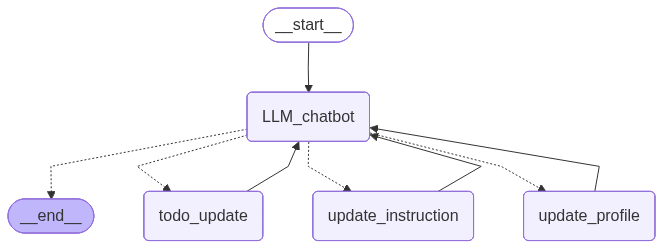

In [300]:
from langgraph.graph import StateGraph, START ,END

workflow = StateGraph(MessagesState)

# add nodes
workflow.add_node('LLM_chatbot' , LLM_chatbot)
workflow.add_node('update_profile' , update_profile)
workflow.add_node('todo_update' , todo_update)
workflow.add_node('update_instruction' , update_instruction)

# add flow
workflow.add_edge(START, 'LLM_chatbot')
workflow.add_conditional_edges('LLM_chatbot', router)
workflow.add_edge('update_profile' , 'LLM_chatbot')
workflow.add_edge('todo_update' , 'LLM_chatbot')
workflow.add_edge('update_instruction' , 'LLM_chatbot')
workflow.add_edge('LLM_chatbot', END)

# set checkpointer and long term memory
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

session_memory = MemorySaver()
store_memory = InMemoryStore()

# compile graph
graph = workflow.compile(checkpointer=session_memory , store=store_memory)

# view
from IPython.display import Image ,display

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

## invoke chat

In [301]:
# set configuration
config = {'configurable': {'thread_id': "1" , 'user_id': "1"}}

user_msg = HumanMessage(content="My name is Diya. I live in SA with my Dog and cat. I have a trecking bike.")

# invoke
chunks = []
for chunk in graph.stream({'messages': [user_msg] } , config , stream_mode="updates"):
    chunks.append(chunk)
    #print(chunk)
    print("-"*30)



[]
[]
[]
------------------------------
------------------------------
[Item(namespace=['UserProfile', '1'], key='bde2616e-75bd-4bc5-b46a-c97d10540793', value={'user_name': 'Diya', 'age': None, 'location': 'SA', 'job': None, 'connections': ['Dog', 'cat'], 'interests': ['trecking bike']}, created_at='2026-06-12T02:09:11.307278+00:00', updated_at='2026-06-12T02:09:11.307278+00:00', score=None)]
[]
[]
------------------------------


### continue the conversation

In [302]:
# set configuration
config = {'configurable': {'thread_id': "1" , 'user_id': "1"}}

user_msg = HumanMessage(content="I need to plan a mountain biking camp next saturday. I love camping . I need a reminder 2 hours before")

# invoke
for chunk in graph.stream({'messages': [user_msg] } , config , stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    print("-"*30)

================================ Human Message =================================

I need to plan a mountain biking camp next saturday. I love camping . I need a reminder 2 hours before
------------------------------
[Item(namespace=['UserProfile', '1'], key='bde2616e-75bd-4bc5-b46a-c97d10540793', value={'user_name': 'Diya', 'age': None, 'location': 'SA', 'job': None, 'connections': ['Dog', 'cat'], 'interests': ['trecking bike']}, created_at='2026-06-12T02:09:11.307278+00:00', updated_at='2026-06-12T02:09:11.307278+00:00', score=None)]
[]
[]
================================== Ai Message ==================================

[]
Tool Calls:
  Updatememory (51BmCsW9)
 Call ID: 51BmCsW9
  Args:
    update_type: update_profile
------------------------------
================================= Tool Message =================================

Profile Memory updated
------------------------------
[Item(namespace=['UserProfile', '1'], key='bde2616e-75bd-4bc5-b46a-c97d10540793', value={'user_name': 'D

### continue conversation

In [303]:
# User input to update instructions for creating ToDos
input_messages = [HumanMessage(content="When creating or updating ToDo items, include specific local businesses / vendors. and how to set up the camping . find solution and update the todo with camping solutions as well")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

When creating or updating ToDo items, include specific local businesses / vendors. and how to set up the camping . find solution and update the todo with camping solutions as well
[Item(namespace=['UserProfile', '1'], key='bde2616e-75bd-4bc5-b46a-c97d10540793', value={'user_name': 'Diya', 'age': None, 'location': 'SA', 'job': None, 'connections': ['Dog', 'cat'], 'interests': ['trecking bike', 'camping']}, created_at='2026-06-12T02:09:18.863156+00:00', updated_at='2026-06-12T02:09:18.863156+00:00', score=None)]
[Item(namespace=['ToDo', '1'], key='71dd5d69-7292-405d-b1dc-3b2393cb32af', value={'task': 'Plan mountain biking camp', 'time_taken': None, 'deadline': '2026-06-20T00:00:00', 'instruction': 'Plan a mountain biking camp. Set a reminder 2 hours before the event.', 'desired_solution': None, 'status': 'not started'}, created_at='2026-06-12T02:09:20.059556+00:00', updated_at='2026-06-12T02:09:20.060047+00

## Add more tasks to see how tasks are added or updated

In [304]:
# User input to update instructions for creating ToDos
user_msg = [HumanMessage(content="I just got an evite to Pooja on july 2nd. Remind me previous day. Also make a list of things i should keep ready including clothes and gifts")]

# Run the graph
for chunk in graph.stream({"messages": user_msg}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I just got an evite to Pooja on july 2nd. Remind me previous day. Also make a list of things i should keep ready including clothes and gifts
[Item(namespace=['UserProfile', '1'], key='bde2616e-75bd-4bc5-b46a-c97d10540793', value={'user_name': 'Diya', 'age': None, 'location': 'SA', 'job': None, 'connections': ['Dog', 'cat'], 'interests': ['trecking bike', 'camping']}, created_at='2026-06-12T02:09:18.863156+00:00', updated_at='2026-06-12T02:09:18.863156+00:00', score=None)]
[Item(namespace=['ToDo', '1'], key='71dd5d69-7292-405d-b1dc-3b2393cb32af', value={'task': 'Plan mountain biking camp', 'time_taken': None, 'deadline': '2026-06-20T00:00:00', 'instruction': 'Plan a mountain biking camp in SA. Include local vendors for bike maintenance and camping gear. Set up camping by choosing a site with water access and fire pits. Set a reminder 2 hours before the event.', 'desired_solution': "Research local SA bike s

### Check Store memory

In [318]:
# set up configuration to check the store
user_id = "1"
namespace = ("ToDo" , user_id)

todo_memory = store_memory.search(namespace)
for m in todo_memory:
    #print(m.value)
    dict = m.value
    for key , value in dict.items():
        print(f"\033[1m{key.capitalize()}: {value}\n") # \033[1m - bold letters
    print("-"*30)

Task: Plan mountain biking camp

Time_taken: None

Deadline: 2026-06-20T00:00:00

Instruction: Plan a mountain biking camp in SA. Include local vendors for bike maintenance and camping gear. Set up camping by choosing a site with water access and fire pits. Set a reminder 2 hours before the event.

Desired_solution: Research local SA bike shops (e.g., 'SA Bike Hub') and camping gear rentals. Select a campsite with amenities. Create a checklist for gear and bike maintenance.

Status: not started

------------------------------
Task: Prepare for Pooja on July 2nd

Time_taken: None

Deadline: 2026-07-01T00:00:00

Instruction: Remind me one day before the Pooja on July 2nd. Create a list of things to keep ready, including clothes and gifts.

Desired_solution: Prepare clothes (traditional attire) and gifts for the Pooja. Ensure everything is ready by the day before.

Status: not started

------------------------------


## To do HTMl Card Disply

In [320]:
from IPython.display import HTML, display
import datetime

def render_task_dashboard(namespace):
    tasks = store_memory.search(namespace)

    if not tasks:
        display(HTML("<h3>No tasks found.</h3>"))
        return

    cards_html = ""

    for m in tasks:
        t = m.value

        task = t.get("task", "Untitled Task")
        status = t.get("status", "unknown")
        deadline = t.get("deadline", None)
        instruction = t.get("instruction", "")
        desired_solution = t.get("desired_solution", "")
        time_taken = t.get("time_taken", None)

        # Color coding for status
        status_color = {
            "completed": "#4CAF50",
            "in progress": "#FFC107",
            "not started": "#F44336"
        }.get(status.lower(), "#9E9E9E")

        # Format deadline
        if deadline:
            try:
                d = datetime.datetime.fromisoformat(deadline)
                deadline_fmt = d.strftime("%b %d, %Y")
            except:
                deadline_fmt = deadline
        else:
            deadline_fmt = "None"

        cards_html += f"""
        <div class="task-card">
            <div class="task-header">
                <span class="task-title">{task}</span>
                <span class="task-status" style="background:{status_color}">{status}</span>
            </div>

            <div class="task-body">
                <p><b>Deadline:</b> {deadline_fmt}</p>
                <p><b>Time Taken:</b> {time_taken}</p>
                <p><b>Instruction:</b> {instruction}</p>
                <p><b>Desired Solution:</b> {desired_solution}</p>
            </div>
        </div>
        """

    html_page = f"""
    <style>
        .task-container {{
            font-family: system-ui, sans-serif;
            margin: 1rem auto;
            max-width: 900px;
        }}
        .task-title {{
            font-size: 1.2rem;
            font-weight: 600;
        }}
        .task-card {{
            border: 1px solid #ddd;
            border-radius: 10px;
            padding: 1rem;
            margin-bottom: 1rem;
            background: #fafafa;
        }}
        .task-header {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: .5rem;
        }}
        .task-status {{
            padding: .3rem .6rem;
            border-radius: 6px;
            color: white;
            font-size: .8rem;
            text-transform: capitalize;
        }}
        .task-body p {{
            margin: .3rem 0;
        }}
    </style>

    <div class="task-container">
        <h2>📝 Task Dashboard</h2>
        {cards_html}
    </div>
    """

    display(HTML(html_page))


# Run the dashboard
render_task_dashboard(namespace)
